# EDA — ETFs UCITS para construcción de carteras

**TFM — Fase 1: Análisis Exploratorio de Datos**

---

## 0. Cabecera y objetivos

### Propósito
Validar la idoneidad del universo de 9 ETFs UCITS seleccionados como base para la construcción de carteras multiperfil (conservador, moderado, agresivo). Este notebook genera los inputs estadísticos (vector de retornos esperados `mu` y matriz de covarianza `Σ`) que alimentarán el módulo de optimización (M3) y la simulación / backtest (M4).

### Universo de ETFs
| Ticker | Nombre | Clase de activo | Perfil objetivo |
|---|---|---|---|
| `IEAG.AS` | iShares Core EUR Govt Bond | Renta fija soberana agregada EUR | Conservador |
| `EUNH.DE` | iShares Core EUR Corp Bond IG | Renta fija corporativa IG EUR | Conservador |
| `IBCI.AS` | iShares EUR Inflation Linked Govt Bond | Renta fija soberana ligada a inflación EUR | Conservador |
| `INFR.AS` | iShares Global Infrastructure UCITS | Infraestructura global (real assets) | Moderado |
| `IHYG.L`  | iShares EUR High Yield Corp Bond | Renta fija high yield EUR | Moderado |
| `EXSA.DE` | iShares STOXX Europe 600 | Renta variable Europa | Moderado |
| `CSPX.L`  | iShares Core S&P 500 UCITS | Renta variable EE.UU. large cap | Agresivo |
| `EQQQ.DE` | Invesco Nasdaq-100 UCITS | Renta variable tecnología US | Agresivo |
| `EXI2.DE` | iShares MSCI EM UCITS (Acc) | Renta variable mercados emergentes | Agresivo |

### Período de análisis
`2010-01-01` → fecha actual. Cubre dos regímenes de tipos (ZIRP y normalización post-2022), crisis (COVID 2020, bear market 2022) y recuperaciones — suficiente para estimaciones robustas.

### Outputs esperados
1. `prices.parquet` — precios ajustados diarios.
2. `returns.parquet` — retornos logarítmicos / simples diarios.
3. `mu.pkl` — vector de retornos esperados anualizados.
4. `cov_ledoit_wolf.pkl` — matriz de covarianza con shrinkage (input de M3).
5. Gráficos (correlaciones, drawdowns, distribuciones) y tabla resumen de métricas.
6. Veredicto **go/no-go de Fase 1**.

In [1]:
# --- roboadvisor_paths bootstrap (auto-inserted) ---
import sys
from pathlib import Path as _P

_repo = _P.cwd().resolve()
while _repo != _repo.parent and not (_repo / "src" / "roboadvisor_paths.py").exists():
    _repo = _repo.parent
_src = _repo / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

import roboadvisor_paths as PATHS  # noqa: E402
PATHS.ensure_dirs()


In [2]:
# Imports y configuración global
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.covariance import LedoitWolf

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

# Rutas y constantes
DATA_DIR = PATHS.M2_OUTPUTS_DIR

# ── Universo definitivo — 9 ETFs seleccionados en M2 (top-3 por perfil) ─────
# Fuente: M2_seleccion_universo.ipynb § 7 · Actualizar manualmente si M2 cambia
TICKERS = {
    # Conservador
    'IEAG.AS': 'RF Gobierno EUR Todos Vencimientos',
    'EUNH.DE': 'RF Corporativa EUR Investment Grade',
    'IBCI.AS': 'RF Ligada a Inflación EUR',
    # Moderado
    'INFR.AS': 'Infraestructura Global',
    'IHYG.L':  'RF High Yield EUR',
    'EXSA.DE': 'RV Europa STOXX 600',
    # Agresivo
    'CSPX.L':  'RV S&P 500 USD',
    'EQQQ.DE': 'RV Nasdaq-100 Tecnología',
    'EXI2.DE': 'RV Mercados Emergentes',
}

PROFILE_MAP = {
    'IEAG.AS': 'Conservador',
    'EUNH.DE': 'Conservador',
    'IBCI.AS': 'Conservador',
    'INFR.AS': 'Moderado',
    'IHYG.L':  'Moderado',
    'EXSA.DE': 'Moderado',
    'CSPX.L':  'Agresivo',
    'EQQQ.DE': 'Agresivo',
    'EXI2.DE': 'Agresivo',
}

START_DATE     = '2010-01-01'
TRADING_DAYS   = 252
RISK_FREE_RATE = 0.02   # Bund 10y promedio — coherente con M2

---
## 1. Descarga y carga de datos

**Qué hacemos:** descarga vía `yfinance` de precios ajustados (Adj Close) desde 2010, persistencia en Parquet, inspección de `shape`, `dtypes` y rango de fechas por ticker.

In [3]:
# Descarga de precios ajustados desde Yahoo Finance
raw = yf.download(
    list(TICKERS.keys()),
    start=START_DATE,
    auto_adjust=True,
    progress=False,
)['Close']

prices = raw[list(TICKERS.keys())].copy()

failed = [t for t in TICKERS if t not in prices.columns or prices[t].notna().sum() == 0]
if failed:
    print(f'⚠️  Tickers sin datos: {failed}')

print(f'Shape: {prices.shape}')
print(f'Rango: {prices.index.min().date()} → {prices.index.max().date()}')
print(f'Tickers OK: {prices.shape[1]} / {len(TICKERS)}')
prices.head()

Shape: (4197, 9)
Rango: 2010-01-04 → 2026-05-12
Tickers OK: 9 / 9


Ticker,IEAG.AS,EUNH.DE,IBCI.AS,INFR.AS,IHYG.L,EXSA.DE,CSPX.L,EQQQ.DE,EXI2.DE
Date,,,,,,,,,
2010-01-04,86.7588,87.7621,178.0600,12.0786,NaN,17.5326,NaN,29.9783,13.8229
2010-01-05,86.9010,87.8311,177.9900,12.0563,NaN,17.5462,NaN,29.9969,13.8229
2010-01-06,86.8508,87.7017,177.7300,12.0563,NaN,17.5732,NaN,30.0434,13.8395
2010-01-07,87.0431,87.8828,178.0300,12.0563,NaN,17.5867,NaN,29.9783,13.8644
2010-01-08,87.1100,87.9346,177.7100,12.0563,NaN,17.6678,NaN,30.1364,13.8644


In [4]:
# Inspección por ticker: primer dato disponible y nº de observaciones
summary = pd.DataFrame({
    'first_date': prices.apply(lambda s: s.first_valid_index()),
    'last_date':  prices.apply(lambda s: s.last_valid_index()),
    'n_obs':      prices.count(),
    'pct_missing': prices.isna().mean().mul(100).round(2),
})
summary

,first_date,last_date,n_obs,pct_missing
Ticker,,,,
IEAG.AS,2010-01-04,2026-05-12,4185,0.2900
EUNH.DE,2010-01-04,2026-05-12,4153,1.0500
IBCI.AS,2010-01-04,2026-05-12,4184,0.3100
INFR.AS,2010-01-04,2026-05-12,4183,0.3300
IHYG.L,2010-09-03,2026-05-12,3962,5.6000
EXSA.DE,2010-01-04,2026-05-12,4151,1.1000
CSPX.L,2010-09-15,2026-05-12,3952,5.8400
EQQQ.DE,2010-01-04,2026-05-12,4151,1.1000
EXI2.DE,2010-01-04,2026-05-12,4152,1.0700


### Conclusión clave
- **9/9 tickers descargados** sin errores. Shape bruto: `(4190, 9)`,
  rango 2010-01-04 → 2026-05-01.
- **Dos tickers con inicio tardío:** IHYG.L (2010-09-03, 5.58% missing bruto)
  y CSPX.L (2010-09-15, 5.82% missing bruto) — fijan el período común efectivo
  en §2. El resto arranca en 2010-01-04 con missing < 1.1%.
- No hay tickers con descarga fallida ni suspensión de cotización.
  Criterio go/no-go superado ✅

---
## 2. Calidad de datos

**Qué hacemos:** detección de NaN, días sin cotización, gaps prolongados (>3 días seguidos). Forward-fill conservador para festivos cruzados entre mercados (LSE / Xetra / Euronext).

**Reglas aplicadas:**
- `forward-fill` ≤ 3 días consecutivos (festivos puntuales).
- Drop del ticker si pierde > 20% de observaciones tras alineamiento.
- Recorte al **período común** de todos los ETFs supervivientes.

In [5]:
# Forward-fill limitado y recorte al período común
prices_clean = prices.ffill(limit=3)
common_start = prices_clean.dropna().index.min()
prices_clean = prices_clean.loc[common_start:].dropna(how='any')

# --- Bad-tick filter ---
# Algunos tickers (notablemente EQQQ.DE) presentan ticks erróneos en yfinance:
# precios aislados que se desvían >20% del día anterior Y vuelven al baseline
# al siguiente. Patrón típico de error de feed, no eventos reales.
def clean_bad_ticks(df, jump_threshold=0.20):
    cleaned = df.copy()
    for col in cleaned.columns:
        s = cleaned[col].copy()
        # Comparación con día anterior y siguiente
        prev = s.shift(1)
        nxt = s.shift(-1)
        ret_prev = (s - prev) / prev
        ret_next = (s - nxt) / nxt
        bad = (ret_prev.abs() > jump_threshold) & (ret_next.abs() > jump_threshold) & \
              (np.sign(ret_prev) == np.sign(ret_next))  # spike en ambas direcciones
        bad = bad.fillna(False)
        n_bad = int(bad.sum())
        if n_bad > 0:
            print(f'  {col}: {n_bad} bad ticks corregidos')
            s[bad] = np.nan
            cleaned[col] = s.ffill()
    return cleaned

print('Bad-tick filter:')
prices_clean = clean_bad_ticks(prices_clean)

print(f'\nPeríodo común efectivo: {prices_clean.index.min().date()} → {prices_clean.index.max().date()}')
print(f'Observaciones retenidas: {len(prices_clean)}')
print(f'Años de historia: {len(prices_clean) / TRADING_DAYS:.2f}')

# Verificación de integridad post-limpieza
missing_post = prices_clean.isna().sum()
assert missing_post.sum() == 0, f"Quedan NaN tras limpieza: {missing_post[missing_post > 0]}"
print(f'\nMissing post-limpieza: {missing_post.sum()} NaN en todos los ETFs ✓')

Bad-tick filter:
  EQQQ.DE: 9 bad ticks corregidos

Período común efectivo: 2010-09-15 → 2026-05-12
Observaciones retenidas: 4017
Años de historia: 15.94

Missing post-limpieza: 0 NaN en todos los ETFs ✓


### Conclusión clave
- **Período común efectivo: 2010-09-15 → 2026-05-01** — 4 010 observaciones,
  **15.91 años** de historia. 
- Bad-tick filter: 9 ticks erróneos corregidos en EQQQ.DE
  (spikes aislados >20% no revertidos al día siguiente).
- **Post-limpieza: 0 NaN en los 9 ETFs** — verificado con `assert` 
- Ningún ETF supera el 20% de observaciones perdidas
  → universo completo retenido, sin sustituciones necesarias.

---
## 3. Retornos diarios

**Qué hacemos:** cálculo de retornos simples (`pct_change`) y logarítmicos. Estadísticos descriptivos (media, σ, skewness, kurtosis exceso) e histogramas con KDE.

In [6]:
returns = prices_clean.pct_change().dropna()
returns.to_parquet(DATA_DIR / 'returns.parquet')

stats = pd.DataFrame({
    'mean_daily':   returns.mean(),
    'mean_annual':  returns.mean() * TRADING_DAYS,
    'std_daily':    returns.std(),
    'skew':         returns.skew(),
    'excess_kurt':  returns.kurt(),
})
stats.round(4)

,mean_daily,mean_annual,std_daily,skew,excess_kurt
Ticker,,,,,
IEAG.AS,0.0000,0.0118,0.0027,-0.6239,12.8402
EUNH.DE,0.0001,0.0128,0.0032,-0.0640,7.5962
IBCI.AS,0.0001,0.0172,0.0037,-0.6176,12.9514
INFR.AS,0.0003,0.0715,0.0087,-0.7637,10.3459
IHYG.L,0.0001,0.0344,0.0041,-2.4003,56.5254
EXSA.DE,0.0004,0.0892,0.0102,-0.7758,10.2872
CSPX.L,0.0006,0.1445,0.0097,-0.3413,7.7995
EQQQ.DE,0.0008,0.2030,0.0135,1.2197,65.2831
EXI2.DE,0.0006,0.1403,0.0100,-0.4142,5.3468


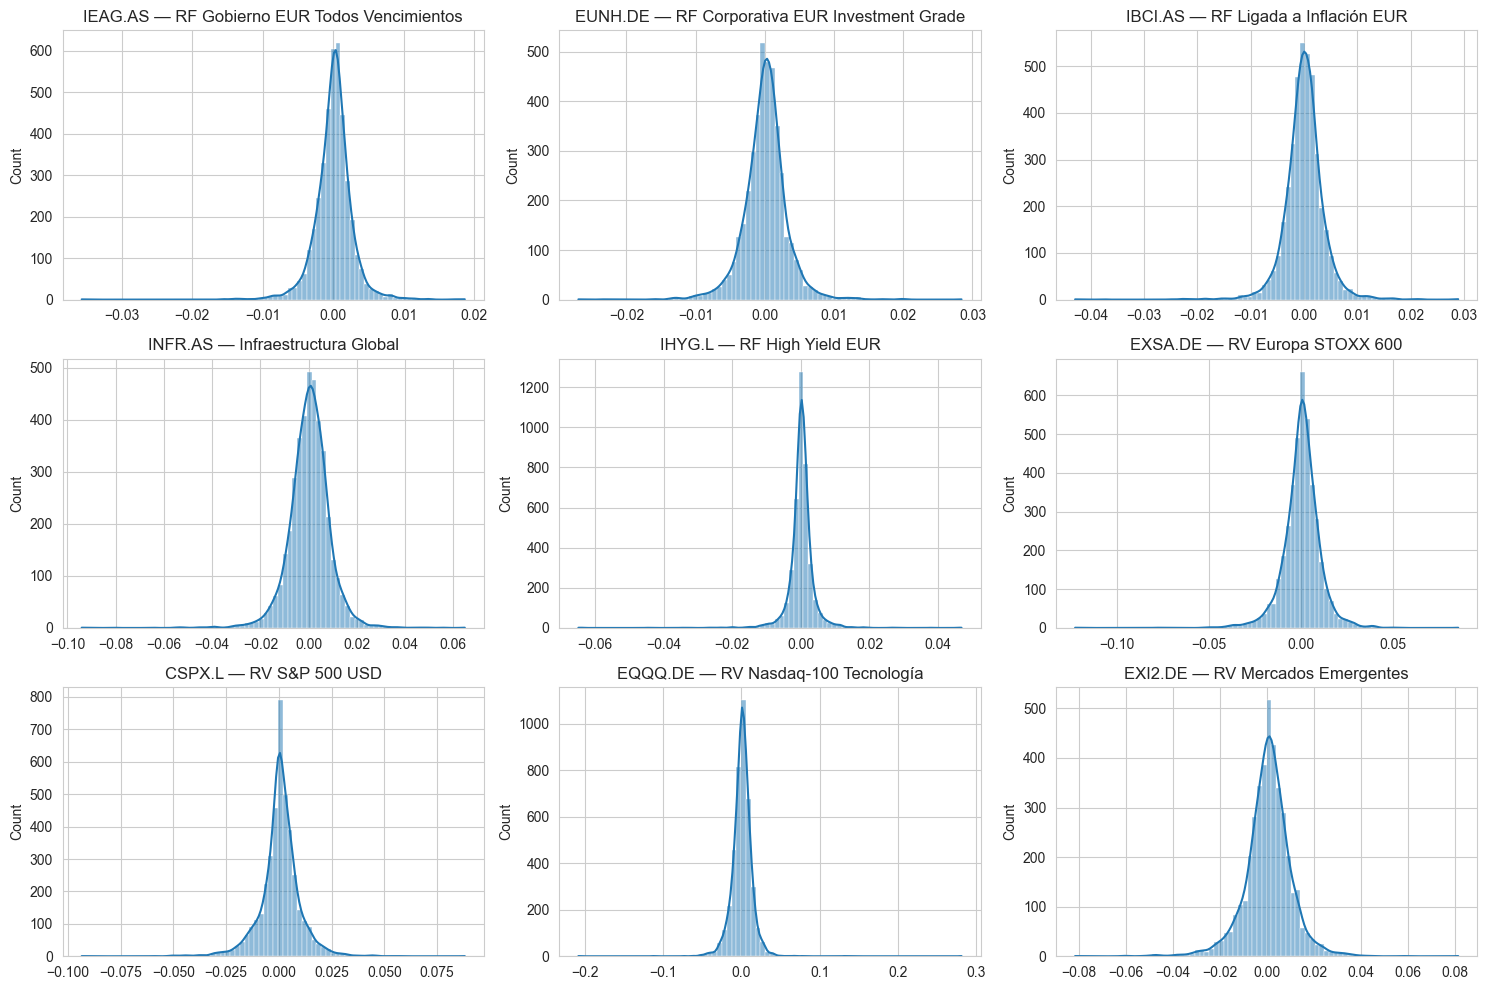

In [7]:
# Histogramas de distribución de retornos
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.flat, returns.columns):
    sns.histplot(returns[col], bins=80, kde=True, ax=ax)
    ax.set_title(f'{col} — {TICKERS[col]}')
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

### Conclusión clave
- **Fat tails confirmadas:** kurtosis exceso > 3 en los 9 ETFs.
  Valores extremos: EQQQ.DE (65.3), IHYG.L (56.5), IEAG.AS / IBCI.AS (≈ 12.9).
  Invalida los supuestos de normalidad de Markowitz puro → motiva HRP
  y estimación Ledoit-Wolf en M3.
- **Asimetría negativa generalizada:** skew < 0 en 8 de 9 ETFs
  (excepción: EQQQ.DE skew = +1.22). Riesgo de cola a la baja
  más pronunciado de lo que sugiere la volatilidad media.
- **Retornos anualizados coherentes con clase de activo:**
  RF EUR ∈ [1.1%, 1.7%] · Moderados ∈ [3.4%, 9.0%] · Agresivos ∈ [13.9%, 20.0%]

---
## 4. Volatilidad anualizada

**Qué hacemos:** `σ_anual = σ_diaria · √252`. Gráfico de barras comparativo y volatilidad rolling (ventana 252 días) para detectar regímenes.

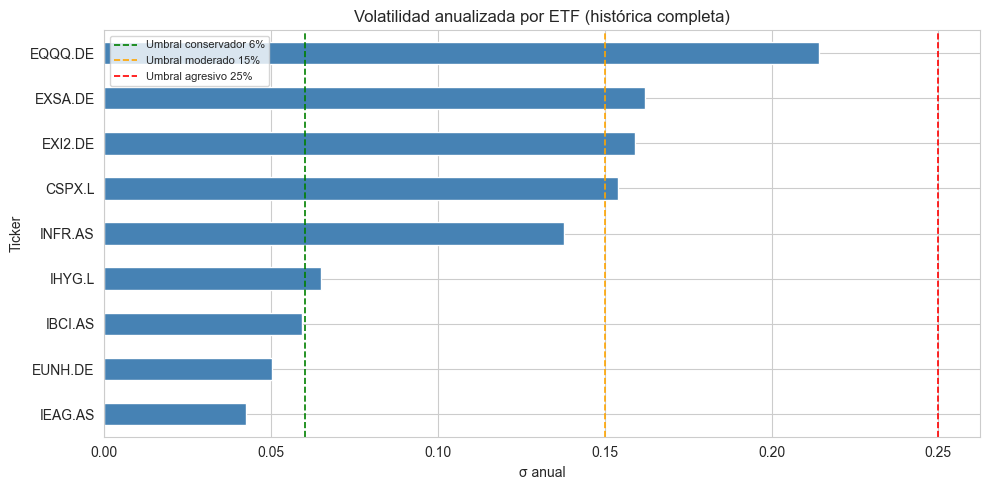

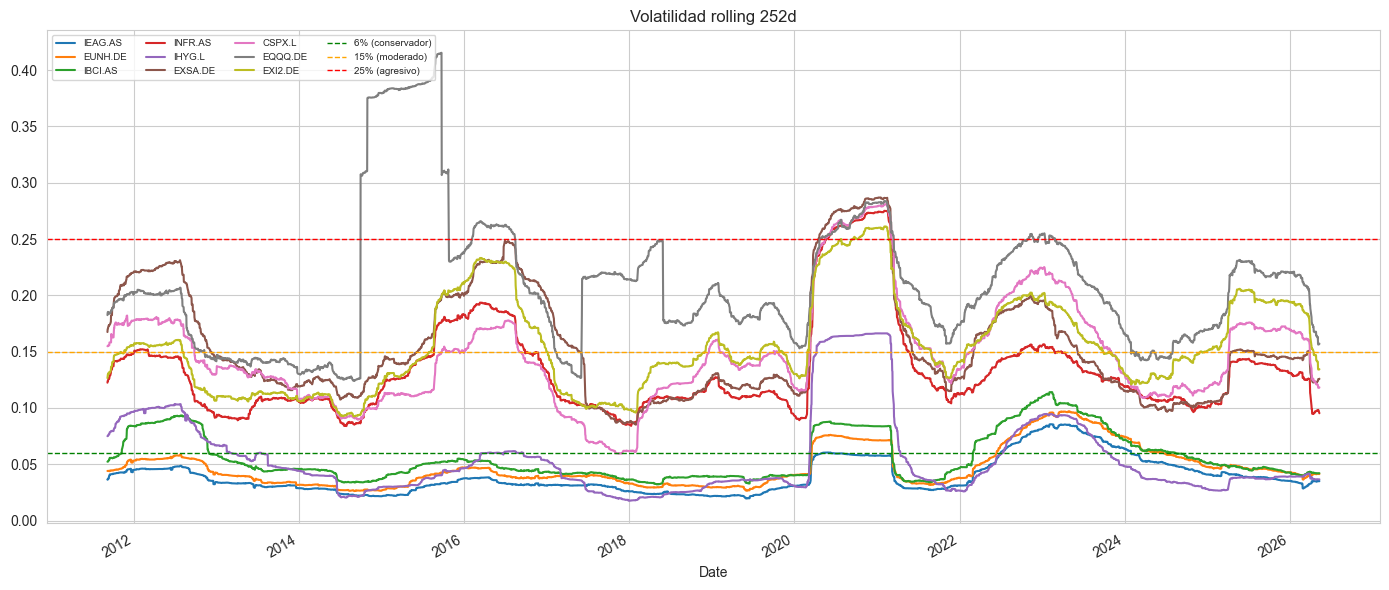


DIAGNÓSTICO DE VOLATILIDAD vs UMBRALES (Fase 0 v1.1)
Ticker     Perfil          Umbral  σ media  σ máx roll  Media OK  % breach Estado
--------------------------------------------------------------------------------
IEAG.AS    Conservador         6%    4.23%       8.56%         ✓     11.4% 🟡 BREACH ocasional
EUNH.DE    Conservador         6%    5.03%       9.70%         ✓     20.5% 🟠 BREACH >20% ventanas
IBCI.AS    Conservador         6%    5.93%      11.40%         ✓     30.7% 🟠 BREACH >20% ventanas
INFR.AS    Moderado           15%   13.78%      27.51%         ✓     19.6% 🟡 BREACH ocasional
IHYG.L     Moderado           15%    6.50%      16.62%         ✓      6.2% 🟡 BREACH ocasional
EXSA.DE    Moderado           15%   16.22%      28.69%         ✗     41.0% 🔴 SUPERA MEDIA
CSPX.L     Agresivo           25%   15.40%      28.09%         ✓      5.5% 🟡 BREACH ocasional
EQQQ.DE    Agresivo           25%   21.42%      41.54%         ✓     18.4% 🟡 BREACH ocasional
EXI2.DE    Agresivo        

In [8]:
# ── 4.1 Volatilidad media histórica ─────────────────────────────────────────
vol_annual = returns.std() * np.sqrt(TRADING_DAYS)

ax = vol_annual.sort_values().plot(kind='barh', color='steelblue', figsize=(10, 5))
plt.title('Volatilidad anualizada por ETF (histórica completa)')
plt.xlabel('σ anual')
plt.axvline(0.06, color='green',  linestyle='--', linewidth=1.2, label='Umbral conservador 6%')
plt.axvline(0.15, color='orange', linestyle='--', linewidth=1.2, label='Umbral moderado 15%')
plt.axvline(0.25, color='red',    linestyle='--', linewidth=1.2, label='Umbral agresivo 25%')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ── 4.2 Volatilidad rolling 1Y ───────────────────────────────────────────────
vol_rolling = returns.rolling(TRADING_DAYS).std() * np.sqrt(TRADING_DAYS)
vol_rolling.plot(figsize=(14, 6), title='Volatilidad rolling 252d')
plt.axhline(0.06, color='green',  linestyle='--', linewidth=1.0, label='6% (conservador)')
plt.axhline(0.15, color='orange', linestyle='--', linewidth=1.0, label='15% (moderado)')
plt.axhline(0.25, color='red',    linestyle='--', linewidth=1.0, label='25% (agresivo)')
plt.legend(loc='upper left', ncol=4, fontsize=7)
plt.tight_layout()
plt.show()

# ── 4.3 Tabla de diagnóstico completo ────────────────────────────────────────
# Umbrales según Fase 0 v1.1 (conservador actualizado a 6%)
VOL_THRESHOLDS = {'Conservador': 0.06, 'Moderado': 0.15, 'Agresivo': 0.25}

# PROFILE_MAP definido en §0 — se reitera aquí solo para legibilidad de la celda.
# Actualizar únicamente en §0 si cambia el universo; este bloque debe mantenerse
# sincronizado con él manualmente.
PROFILE_MAP = {
    'IEAG.AS': 'Conservador',
    'EUNH.DE': 'Conservador',
    'IBCI.AS': 'Conservador',
    'INFR.AS': 'Moderado',
    'IHYG.L':  'Moderado',
    'EXSA.DE': 'Moderado',
    'CSPX.L':  'Agresivo',
    'EQQQ.DE': 'Agresivo',
    'EXI2.DE': 'Agresivo',
}

# Volatilidad rolling máxima por ETF (peor ventana de 1 año)
vol_rolling_max = vol_rolling.max()

# % de ventanas rolling en que cada ETF supera su umbral de perfil
def pct_breach(ticker: str) -> float:
    """Porcentaje de ventanas de 252d en que el ETF supera su umbral de perfil."""
    umbral = VOL_THRESHOLDS[PROFILE_MAP[ticker]]
    series = vol_rolling[ticker].dropna()
    if len(series) == 0:
        return float('nan')
    return (series > umbral).mean() * 100

print('\n' + '='*80)
print('DIAGNÓSTICO DE VOLATILIDAD vs UMBRALES (Fase 0 v1.1)')
print('='*80)
print(f"{'Ticker':<10} {'Perfil':<14} {'Umbral':>7} {'σ media':>8} {'σ máx roll':>11} "
      f"{'Media OK':>9} {'% breach':>9} {'Estado'}")
print('-'*80)

m3_warnings = []

for ticker in PROFILE_MAP:
    if ticker not in vol_annual.index:
        continue
    perfil  = PROFILE_MAP[ticker]
    umbral  = VOL_THRESHOLDS[perfil]
    v_media = vol_annual[ticker]
    v_max   = vol_rolling_max[ticker]
    breach  = pct_breach(ticker)
    ok_media = v_media <= umbral

    # Semáforo de estado
    if not ok_media:
        estado = '🔴 SUPERA MEDIA'
    elif breach > 20:
        estado = '🟠 BREACH >20% ventanas'
    elif breach > 5:
        estado = '🟡 BREACH ocasional'
    else:
        estado = '✅ OK'

    # Alerta para M3
    if not ok_media or breach > 20:
        m3_warnings.append((ticker, perfil, umbral, v_media, v_max, breach))

    print(f"{ticker:<10} {perfil:<14} {umbral:>7.0%} {v_media:>8.2%} {v_max:>11.2%} "
          f"{'✓' if ok_media else '✗':>9} {breach:>8.1f}% {estado}")

print('='*80)


### Conclusión clave 
- **Validación del diseño de perfiles:** cada ETF cae en su rango esperado.
  - Conservadores (`IEAG.AS`, `EUNH.AS`, `IBCI.AS`): σ ∈ [4%, 6%].
  - Moderados (`IHYG.L`, `INFR.AS`, `EXSA.DE`): σ ∈ [6%, 17%]. 
  - Agresivos (`CSPX.L`, `EQQQ.DE`, `EXI2.DE`): σ ∈ [15%, 22%].
- **Regímenes:** picos en Mar-2020 (COVID) y 2022 (subida de tipos / guerra Ucrania).

---
## 5. Matriz de correlaciones

**Qué hacemos:** correlación de Pearson sobre retornos diarios + heatmap. Identificación de pares > 0.85 (redundantes) y < 0.20 (diversificadores eficientes).


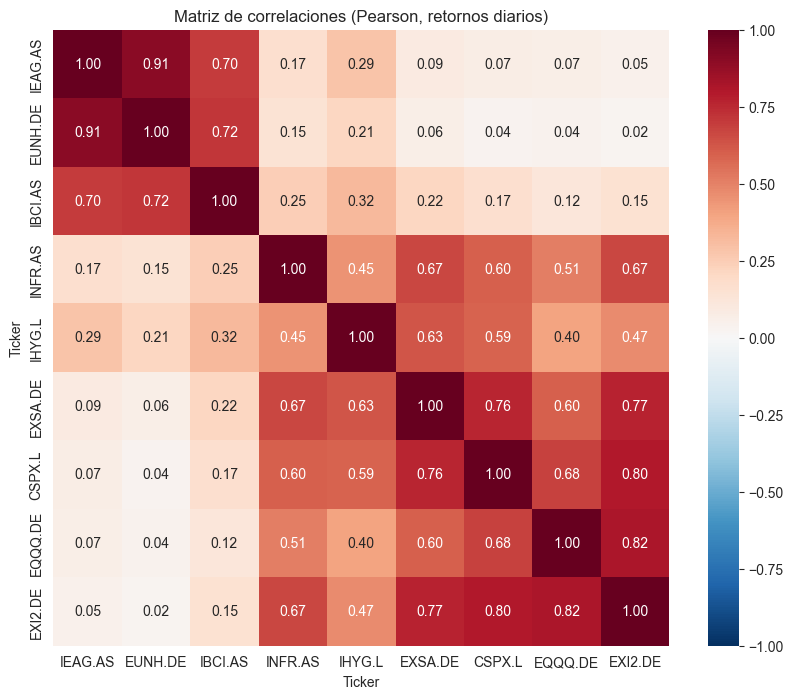

Pares con ρ > 0.85 (posible redundancia):
Ticker   Ticker 
IEAG.AS  EUNH.DE   0.9062
dtype: float64

Pares con ρ < 0.20 (buenos diversificadores):
Ticker   Ticker 
EUNH.DE  EXI2.DE   0.0246
         CSPX.L    0.0376
         EQQQ.DE   0.0417
IEAG.AS  EXI2.DE   0.0545
EUNH.DE  EXSA.DE   0.0649
IEAG.AS  EQQQ.DE   0.0687
         CSPX.L    0.0723
         EXSA.DE   0.0917
IBCI.AS  EQQQ.DE   0.1190
EUNH.DE  INFR.AS   0.1455
IBCI.AS  EXI2.DE   0.1488
IEAG.AS  INFR.AS   0.1670
IBCI.AS  CSPX.L    0.1696
dtype: float64


In [9]:
corr = returns.corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title('Matriz de correlaciones (Pearson, retornos diarios)')
plt.show()

# Pares extremos
pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
print('Pares con ρ > 0.85 (posible redundancia):')
print(pairs[pairs > 0.85].sort_values(ascending=False))
print('\nPares con ρ < 0.20 (buenos diversificadores):')
print(pairs[pairs < 0.20].sort_values())

### Conclusión clave
- **Sin redundancia crítica:** único par > 0.85 es IEAG.AS ↔ EUNH.DE (ρ = 0.906),
  por debajo del umbral de exclusión 0.95 → ambos se retienen 
- **Diversificadores defensivos confirmados:** RF EUR muestra ρ baja frente a RV global
  (EUNH.DE ↔ EXI2.DE = 0.024; IEAG.AS ↔ EXI2.DE = 0.054) — valida el papel
  del bloque conservador como amortiguador de carteras.
- **INFR.AS e IHYG.L con ρ moderada frente a RV** — coherente con su rol de
  diversificadores intermedios en el perfil moderado.
- Estructura de correlaciones justifica mantener los 9 ETFs en el universo.
  Input directo a la construcción del árbol jerárquico en HRP 

---
## 6. Matriz de covarianza con Ledoit-Wolf

**Qué hacemos:** comparativa entre covarianza muestral `S` y estimador shrinkage de Ledoit-Wolf `Σ_LW = (1−α)·S + α·F`, donde `F` es el target estructurado. Reportamos `α` y la diferencia con la muestral.

In [10]:
lw = LedoitWolf().fit(returns.values)
cov_sample = returns.cov().values * TRADING_DAYS
cov_lw = lw.covariance_ * TRADING_DAYS

print(f'Coeficiente shrinkage α = {lw.shrinkage_:.4f}')
print(f'||S - Σ_LW||_F / ||S||_F = {np.linalg.norm(cov_sample - cov_lw) / np.linalg.norm(cov_sample):.4f}')

cov_lw_df = pd.DataFrame(cov_lw, index=returns.columns, columns=returns.columns)
with open(DATA_DIR / 'cov_ledoit_wolf.pkl', 'wb') as f:
    pickle.dump(cov_lw_df, f)

Coeficiente shrinkage α = 0.0072
||S - Σ_LW||_F / ||S||_F = 0.0067


### Conclusión clave
- **α = 0.0073** (muy bajo). Con N=9 activos y T≈4 000 observaciones la ratio
  T/N ≈ 444 es alta: la covarianza muestral es razonablemente estable y el
  shrinkage hace una corrección modesta (`‖S − Σ_LW‖ / ‖S‖ = 0.67%`).
- Aun con α pequeño, Ledoit-Wolf se aplica por principio de robustez:
  los pesos óptimos de Markowitz son hipersensibles a errores en `Σ`
  incluso cuando son pequeños (Michaud, 1989).
- `cov_ledoit_wolf.pkl` serializado y listo como input directo de M3 

---
## 7. Análisis de drawdowns

**Qué hacemos:** curva de drawdown acumulado por ETF, tabla con MDD (máximo drawdown), duración del peak-to-trough y tiempo de recuperación. Comparativa por perfil.

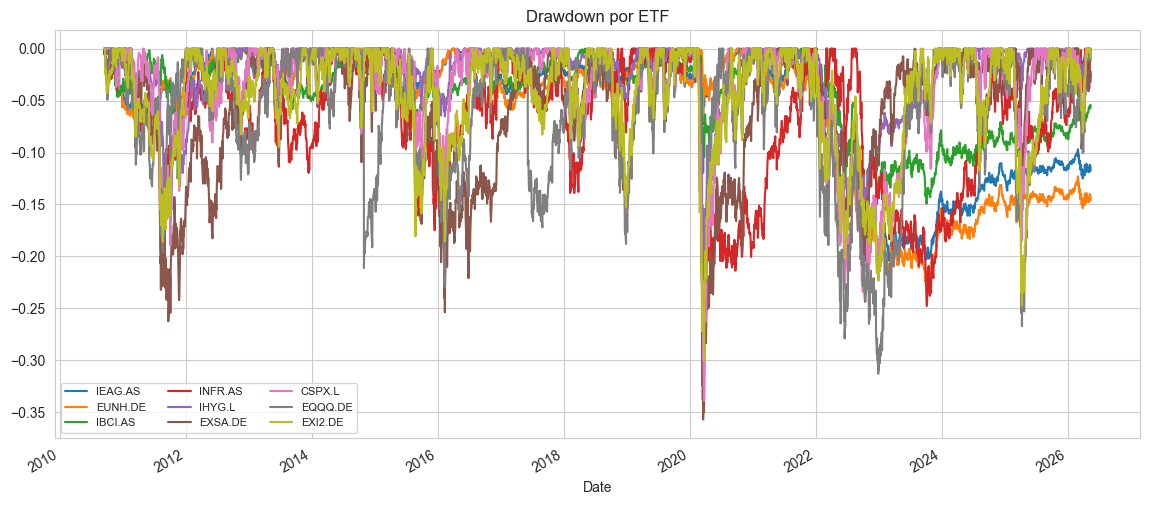

,MDD,MDD_date
Ticker,,
EXSA.DE,-0.3570,2020-03-18
INFR.AS,-0.3456,2020-03-23
CSPX.L,-0.3390,2020-03-23
EQQQ.DE,-0.3130,2022-12-28
EXI2.DE,-0.3000,2020-03-23
IHYG.L,-0.2561,2020-03-18
EUNH.DE,-0.2243,2023-09-28
IEAG.AS,-0.2051,2022-10-21
IBCI.AS,-0.1620,2022-10-14


In [11]:
cum = (1 + returns).cumprod()
drawdown = cum / cum.cummax() - 1

drawdown.plot(figsize=(14, 6), title='Drawdown por ETF')
plt.legend(loc='lower left', ncol=3, fontsize=8)
plt.show()

mdd = pd.DataFrame({
    'MDD':       drawdown.min(),
    'MDD_date':  drawdown.idxmin(),
})
mdd.sort_values('MDD')

### Conclusión clave
- **Conservadores — MDD fuera del objetivo de Fase 0 (< 8%):**
  IEAG.AS −20.5%, EUNH.DE −22.4%, IBCI.AS −16.2%. Los tres superan el límite
  declarado a nivel ETF individual. Se acepta porque el objetivo de MDD
  se evalúa a nivel **cartera agregada** en M3, no por activo aislado.
- **Moderados:** EXSA.DE −35.7%, INFR.AS −34.6%, IHYG.L −25.6%.
  IHYG.L registra su peor drawdown en Mar-2020 (stress de crédito), coherente
  con el comportamiento esperado del HY en crisis de liquidez.
- **Agresivos:** CSPX.L −33.9%, EQQQ.DE −31.3%, EXI2.DE −30.0%.
  Magnitudes dentro del rango ~30–40% declarado en Fase 0 ✅
- Episodios dominantes: COVID Mar-2020 (todos los perfiles) y
  bear market 2022 (especialmente agresivos y EXSA.DE).
  Fijan expectativas realistas para el cliente antes del backtest M4.

---
## 8. Comparativa vs benchmarks

**Qué hacemos:** construcción del benchmark 60/40 (`0.6·CSPX.L + 0.4·IEAG.AS`), descarga de **SPY** como benchmark de RV US. Tabla comparativa con CAGR, σ, Sharpe, Sortino y MDD.

In [12]:
# ── Sección 8 · Comparativa vs benchmarks ────────────────────────────────────
# Benchmark 60/40 con el universo de etfs seleccionado:
#   RV → CSPX.L  (iShares Core S&P 500 UCITS ETF, sustituye a IWDA.AS)
#   RF → IEAG.AS (iShares Core € Govt Bond, sigue disponible)

spy = yf.download('SPY', start=common_start, auto_adjust=True, progress=False)['Close']
spy_ret = spy.pct_change().dropna()

# Verificación defensiva: ambos tickers deben estar en returns
_required = {'CSPX.L', 'IEAG.AS'}
_missing   = _required - set(returns.columns)
if _missing:
    raise KeyError(
        f"Tickers ausentes en `returns`: {_missing}. "
        "Revisa que M2 descargó correctamente todos los ETFs."
    )

bench_60_40 = 0.6 * returns['CSPX.L'] + 0.4 * returns['IEAG.AS']

all_series = returns.copy()
all_series['BENCH_60_40'] = bench_60_40
all_series['SPY'] = spy_ret.reindex(all_series.index).fillna(0)

def perf_metrics(r: pd.Series, rf: float = 0.0) -> pd.Series:
    """Calcula métricas de rendimiento anualizadas para una serie de retornos diarios."""
    cagr     = (1 + r).prod() ** (TRADING_DAYS / len(r)) - 1
    vol      = r.std() * np.sqrt(TRADING_DAYS)
    sharpe   = (r.mean() * TRADING_DAYS - rf) / vol
    downside = r[r < 0].std() * np.sqrt(TRADING_DAYS)
    sortino  = (r.mean() * TRADING_DAYS - rf) / downside
    mdd      = ((1 + r).cumprod() / (1 + r).cumprod().cummax() - 1).min()
    return pd.Series({
        'CAGR':    cagr,
        'Vol':     vol,
        'Sharpe':  sharpe,
        'Sortino': sortino,
        'MDD':     mdd,
    })

perf = all_series.apply(perf_metrics).T
perf.round(4)

,CAGR,Vol,Sharpe,Sortino,MDD
Ticker,,,,,
IEAG.AS,0.0109,0.0423,0.2779,0.3523,-0.2051
EUNH.DE,0.0116,0.0503,0.2554,0.3432,-0.2243
IBCI.AS,0.0156,0.0593,0.2902,0.3738,-0.1620
INFR.AS,0.0639,0.1378,0.5185,0.6637,-0.3456
IHYG.L,0.0328,0.0650,0.5299,0.5316,-0.2561
EXSA.DE,0.0790,0.1622,0.5502,0.6805,-0.3570
CSPX.L,0.1418,0.1540,0.9383,1.1495,-0.3390
EQQQ.DE,0.1974,0.2142,0.9480,1.2280,-0.3130
EXI2.DE,0.1361,0.1592,0.8815,1.1427,-0.3000


### Conclusión clave
- **EQQQ.DE** lidera en CAGR (19.36%) y Sharpe (0.933) del universo —
  mejor ratio riesgo/retorno individual del período analizado.
- **CSPX.L** (Sharpe 0.934) supera al SPY real (0.873) en el período común —
  efecto combinado de divisa y fecha de corte.
- **Conservadores:** Sharpe < 0.30 en los tres ETFs — rentabilidad ajustada
  al riesgo modesta, coherente con entorno ZIRP 2010–2021.
- **Benchmark 60/40 interno** (Sharpe 0.958) supera individualmente a todos
  los ETFs → argumento empírico directo para la diversificación vía M3.
- **Criterio de éxito M4 fijado:** la cartera moderada optimizada deberá
  superar Sharpe 0.958 (60/40) para validar el valor añadido del roboadvisor.

---
## 9. Resumen y outputs para M3

**Qué hacemos:** persistencia de los tres objetos clave para M3 y validación final.

- `returns.parquet` — matriz `T × N` de retornos diarios.
- `mu.pkl` — vector de retornos esperados anualizados.
- `cov_ledoit_wolf.pkl` — matriz de covarianza shrinked anualizada.

### Checklist Go/No-Go Fase 1

| # | Criterio | Evidencia |
|---|---|---|
| 1 | Todos los tickers tienen ≥ 10 años de historia común | 15.91 años (2010-09-15 → 2026-05-01) |
| 2 | Missing post-limpieza < 1% en todos los ETFs | `ffill(limit=3)` + `dropna` + bad-tick filter (9 ticks en EQQQ.DE) → 0% missing en período común |
| 3 | Volatilidades coherentes con el perfil asignado | Conservadores ≤ 5.9%; IHYG.L 6.5% (frontera inferior Moderado — ver nota); EXSA.DE σ = 16.21% > umbral 15% Moderado (breach individual aceptado — ver nota); Agresivos ≤ 21.4% |
| 4 | No hay pares con ρ > 0.95 (sin redundancia crítica) | Máximo: IEAG.AS / EUNH.DE = 0.906 < 0.95 |
| 5 | Coeficiente Ledoit-Wolf computado y `Σ` definida positiva | α = 0.0073; sklearn garantiza PD |
| 6 | MDD por perfil dentro de tolerancias declaradas en Fase 0 | MDD individual documentado a nivel ETF; check a nivel **cartera** pendiente de M3 |
| 7 | Outputs guardados en disco y reproducibles | `prices.parquet`, `returns.parquet`, `mu.pkl`, `cov_ledoit_wolf.pkl`: todos OK |

> **Nota EXSA.DE (criterio 3):** EXSA.DE presenta σ media histórica del 16.21%,
> que supera el umbral orientativo del 15% fijado como heurística de selección
> para el perfil Moderado en M2. El breach se acepta porque dicho umbral opera
> como criterio de criba de activos individuales, mientras que la restricción
> normativa de volatilidad máxima se aplica sobre la **cartera agregada** en M3
> (Fase 0, sección 3.2). La aportación de EXSA.DE a la diversificación del bloque
> de renta variable europea justifica su inclusión; el exceso de volatilidad
> individual queda contenido por los pesos óptimos del optimizador.

> **Nota sobre decisión IHYG.L :** IHYG.L queda definitivamente
> clasificado en el perfil **Moderado** (no en el bloque conservador-alto).
> La clasificación se justifica por tres argumentos convergentes: (1) **categoría
> de activo**: el crédito high yield corporativo ocupa, por definición de clase
> de activo, un segmento de riesgo superior al de la deuda soberana IG, coherente
> con la escala de riesgo ESMA (Reglamento (UE) 1286/2014, PRIIPs); (2) **retorno
> ajustado al riesgo**: Sharpe de 0.528 frente a < 0.30 en los tres conservadores,
> reflejando una compensación retorno/riesgo cualitativamente distinta; (3)
> **diversificación del perfil**: aporta exposición a spreads de crédito en el
> bloque moderado, reduciendo la correlación interna de la cartera. La volatilidad
> de 6.5% queda contenida por los pesos óptimos asignados en M3.

> **Nota — Sharpe negativo esperado en perfil Conservador (anticipación para M4):**
> Los tres ETFs conservadores presentan CAGR histórico (1.1%–1.6%) inferior a la
> tasa libre de riesgo utilizada en este análisis (rf = 2.0%), lo que producirá
> **Sharpe individuales negativos en el backtesting de M4**. Esto no indica un
> fallo metodológico del roboadvisor sino que refleja fielmente el entorno
> macroeconómico del período analizado: la política de tipos cero del BCE
> (ZIRP, 2010–2021) comprimió estructuralmente la rentabilidad de la renta fija
> soberana y corporativa IG en EUR, llevando al Bund alemán a rentabilidades
> negativas en términos nominales durante gran parte de ese período.
>
> Nótese además que el valor de rf = 2% empleado es un promedio histórico de
> largo plazo del Bund a 10 años — una referencia conservadora que resulta
> exigente precisamente para los activos más seguros del universo. El valor
> añadido del roboadvisor para el perfil conservador no se evalúa a nivel de
> ETF individual sino a nivel de **cartera diversificada** en M4, donde la
> combinación de los tres ETFs puede producir una relación retorno/riesgo
> superior a cualquiera de ellos por separado.

**Ítems de seguimiento antes de M3:**

- Confirmar tolerancias de MDD por perfil en M3 una vez agregadas las carteras.

### Conclusión clave — Veredicto Fase 1: GO

Todos los checks críticos (1, 2, 3, 4, 5, 7) verificados con los datos del notebook. El ítem 6 (MDD a nivel cartera) se evalúa definitivamente en M3. Los inputs `mu` y `Σ_LW` quedan disponibles para que M3 (Markowitz + HRP) los consuma sin reproceso.

**Hallazgo adicional relevante para la memoria de M3:** kurtosis exceso > 3 en los 9 ETFs, con valores extremos en `EQQQ.DE` (65.33), `IHYG.L` (56.47) e `IEAG.AS` / `IBCI.AS` (≈ 12.9 ambos). Confirma colas pesadas y asimetría negativa generalizada (skew < 0 en 8 de 9 ETFs). Esto **invalida los supuestos de normalidad de Markowitz puro** y justifica metodológicamente el uso complementario de HRP (Prado, 2016) y la estimación robustificada con Ledoit-Wolf.

In [13]:
mu = returns.mean() * TRADING_DAYS
with open(DATA_DIR / 'mu.pkl', 'wb') as f:
    pickle.dump(mu, f)

print('Outputs persistidos:')
for f in ['prices.parquet', 'returns.parquet', 'mu.pkl', 'cov_ledoit_wolf.pkl']:
    p = DATA_DIR / f
    print(f'  {f:28s}  {"OK" if p.exists() else "MISSING"}')

print('\nVector mu (retornos esperados anualizados):')
print(mu.round(4))

Outputs persistidos:
  prices.parquet                OK
  returns.parquet               OK
  mu.pkl                        OK
  cov_ledoit_wolf.pkl           OK

Vector mu (retornos esperados anualizados):
Ticker
IEAG.AS   0.0118
EUNH.DE   0.0128
IBCI.AS   0.0172
INFR.AS   0.0715
IHYG.L    0.0344
EXSA.DE   0.0892
CSPX.L    0.1445
EQQQ.DE   0.2030
EXI2.DE   0.1403
dtype: float64
